# Banking Financial Health Classification: Data Generation

**Project:** ARB Apex Bank - Rural Banking Risk Assessment System  

---

## Objective
Generate synthetic dataset of 224 rural banks with quarterly financial metrics over 3 years (12 quarters) to replicate real-world banking supervision analysis.

## Dataset Specifications
- **Banks:** 224 institutions
- **Time Period:** 12 quarters (Q1 2021 - Q4 2023)
- **Features:** 25+ financial and operational variables
- **Target:** Binary classification - HIGH_RISK (1) vs HEALTHY (0)
- **Class Distribution:** 30-35% high-risk banks

## Data Generation Strategy
1. Create bank profiles with realistic size distribution
2. Generate base financial metrics with logical constraints
3. Apply temporal autocorrelation for realistic quarter-to-quarter changes
4. Introduce regional economic shocks
5. Add realistic noise and measurement error
6. Ensure feature correlations (NPL-> profitability, liquidity -> risk)
7. Create target variable based on regulatory thresholds

**Note:** This is synthetic data created for portfolio purposes. Original analysis used confidential banking data.

# Setup and Dependencies 

In [24]:
%pip install faker

Note: you may need to restart the kernel to use updated packages.


In [25]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from faker import Faker
import warnings
from datetime import datetime
import os

# Configuration
warnings.filterwarnings('ignore')
np.random.seed(42)  # Reproducibility
fake = Faker()
Faker.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


# Define Configuration Parameters 

In [26]:
#Dataset configuration 
CONFIG = {
    'n_banks': 224,
    'n_quarters': 12,
    'start_year': 2021,
    'start_quarter': 1,
    
    #Reginal distribution(10 regions)
    'regions': ['Greater Accra', 'Ashanti', 'Western', 'Eastern', 'Central', 
                'Northern', 'Volta', 'Upper East', 'Upper West', 'Bono'],
    #Bank size distribution 
    'bank_sizes': {
        'Small': 0.40,
        'Medium': 0.45,
        'Large': 0.15
    },
    
     # Target class distribution
    'target_high_risk_ratio': 0.33,  # 33% high-risk banks
    
    # Missing value parameters
    'missing_rate': 0.05,  # 5% missing values in operational metrics
    
    # Noise parameters
    'noise_std': 0.05,  # ±5% standard deviation for noise
    
    # Temporal autocorrelation
    'autocorr_weight': 0.7  # 70% weight to previous quarter
    
}

print("Configuration loaded:")
print(f"Total banks: {CONFIG['n_banks']}")
print(f"Quarters: {CONFIG['n_quarters']}")
print(f"Total records: {CONFIG['n_banks'] * CONFIG['n_quarters']:,}")
print(f"Regions: {len(CONFIG['regions'])}")
print(f"Expected high-risk banks: ~{int(CONFIG['n_banks'] * CONFIG['target_high_risk_ratio'])}")

Configuration loaded:
Total banks: 224
Quarters: 12
Total records: 2,688
Regions: 10
Expected high-risk banks: ~73


# Generate Bank Profiles 

In [27]:
def generate_bank_profiles(n_banks, regions, size_distribution):
    """"
    Generate static bank profile data.
    
    Args:
        n_banks: Number of banks to generate 
        regions: Lisr of regions names
        size_distribution: Dictionary with size categories and proportions 
        
    Returns:
        DataFrame with bank profiles 
    
    
    """
    
    bank_profiles = []
    
    for i in range(1, n_banks + 1):
        #Generate bank size based on distribution 
        bank_size = np.random.choice(
            list(size_distribution.keys()),
            p=list(size_distribution.values())
        )
        
        #Assign regions (some regions have more banks than others)
        region_weights = [0.20, 0.18, 0.12, 0.10, 0.10, 0.08, 0.07, 0.06, 0.05, 0.04]
        region = np.random.choice(regions, p=region_weights)
        
        #Generate bank persona (lending style)
        lending_style= np.random.choice(
            ['Conservative', 'Moderate', 'Aggressive'],
            p=[0.30, 0.50, 0.20]
        )
        
        bank_profiles.append({
            'bank_id': f'BANK_{i:03d}',
            'bank_name': f'{fake.company()} Rural Bank',
            'region': region,
            'bank_size': bank_size,
            'lending_style': lending_style,
            'established_year': np.random.randint(1995, 2020)  
        })
    return pd.DataFrame(bank_profiles)

# Generate bank profiles
bank_profiles_df = generate_bank_profiles(
    CONFIG['n_banks'], 
    CONFIG['regions'], 
    CONFIG['bank_sizes']
)

print("Bank profiles generated successfully")
print(f"\nBank Size Distribution:")
print(bank_profiles_df['bank_size'].value_counts())
print(f"\nRegional Distribution (Top 5):")
print(bank_profiles_df['region'].value_counts().head())
print(f"\nLending Style Distribution:")
print(bank_profiles_df['lending_style'].value_counts())
print(f"\nSample Bank Profiles:")
bank_profiles_df.head()

Bank profiles generated successfully

Bank Size Distribution:
bank_size
Small     102
Medium     92
Large      30
Name: count, dtype: int64

Regional Distribution (Top 5):
region
Greater Accra    46
Eastern          37
Ashanti          36
Western          21
Central          20
Name: count, dtype: int64

Lending Style Distribution:
lending_style
Moderate        108
Conservative     70
Aggressive       46
Name: count, dtype: int64

Sample Bank Profiles:


,bank_id,bank_name,region,bank_size,lending_style,established_year
0,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,2015
1,BANK_002,Doyle Ltd Rural Bank,Greater Accra,Small,Conservative,2018
2,BANK_003,"Mcclain, Miller and Henderson Rural Bank",Greater Accra,Small,Moderate,2015
3,BANK_004,Davis and Sons Rural Bank,Volta,Large,Conservative,2015
4,BANK_005,"Guzman, Hoffman and Baldwin Rural Bank",Central,Medium,Conservative,2019


# Define Financial Metric Generators 

In [28]:
def get_base_ranges(bank_size, lending_style):
    """
    Get base value ranges for financial metrics based on bank characteristics.
    
    Args:
        bank_size: 'Small', 'Medium', or 'Large'
        lending_style: 'Conservative', 'Moderate', or 'Aggressive'
    
    Returns:
        Dictionary with base ranges for each metric
    """
    # Base asset ranges by size (in millions)
    asset_ranges = {
        'Small': (5, 50),
        'Medium': (50, 200),
        'Large': (200, 800)
    }
    
    # Liquidity ratio adjustments by lending style
    liquidity_adjust = {
        'Conservative': (20, 45),
        'Moderate': (15, 35),
        'Aggressive': (5, 25)
    }
    
    # NPL ratio adjustments
    npl_adjust = {
        'Conservative': (0, 8),
        'Moderate': (3, 15),
        'Aggressive': (8, 25)
    }
    
    return {
        'total_assets': asset_ranges[bank_size],
        'liquidity_ratio': liquidity_adjust[lending_style],
        'npl_ratio': npl_adjust[lending_style],
        'capital_adequacy_ratio': (8, 30),
        'loan_to_deposit_ratio': (40, 95)
    }

def generate_correlated_metrics(base_value, correlation_factors, noise_std=0.05):
    """
    Generate correlated financial metrics.
    
    Args:
        base_value: Base metric value
        correlation_factors: Dict of factors affecting the metric
        noise_std: Standard deviation of noise
    
    Returns:
        Adjusted value with correlations and noise
    """
    adjusted_value = base_value
    
    # Apply correlation factors
    for factor_value, factor_weight in correlation_factors.items():
        adjusted_value *= (1 + factor_value * factor_weight)
    
    # Add noise
    noise = np.random.normal(0, noise_std)
    adjusted_value *= (1 + noise)
    
    return adjusted_value

print("Financial metric generator functions defined")
print("\nExample base ranges for Medium Conservative bank:")
example_ranges = get_base_ranges('Medium', 'Conservative')
for metric, range_val in example_ranges.items():
    print(f"  {metric}: {range_val}")

Financial metric generator functions defined

Example base ranges for Medium Conservative bank:
  total_assets: (50, 200)
  liquidity_ratio: (20, 45)
  npl_ratio: (0, 8)
  capital_adequacy_ratio: (8, 30)
  loan_to_deposit_ratio: (40, 95)


# Genrate Quarterly Financial Data 

In [29]:
def generate_quarterly_data(bank_profile, quarter_num, previous_metrics=None, regional_shock=0):
    """
    Generate quarterly financial metrics for a single bank.
    
    Args:
        bank_profile: Dictionary with bank profile info
        quarter_num: Quarter number (1-12)
        previous_metrics: Previous quarter metrics for temporal correlation
        regional_shock: Economic shock factor for the region (-0.2 to 0.2)
    
    Returns:
        Dictionary with quarterly metrics
    """
    ranges = get_base_ranges(bank_profile['bank_size'], bank_profile['lending_style'])
    
    # Generate or update total assets
    if previous_metrics is None:
        total_assets = np.random.uniform(*ranges['total_assets'])
    else:
        # Temporal autocorrelation with small growth/decline
        growth_rate = np.random.normal(0.02, 0.05) + regional_shock
        total_assets = previous_metrics['total_assets'] * (1 + growth_rate)
    
    # Generate capital metrics
    if previous_metrics is None:
        capital_adequacy_ratio = np.random.uniform(*ranges['capital_adequacy_ratio'])
    else:
        # CAR changes slowly
        car_change = np.random.normal(0, 0.01)
        capital_adequacy_ratio = previous_metrics['capital_adequacy_ratio'] * (1 + car_change)
        capital_adequacy_ratio = np.clip(capital_adequacy_ratio, 6, 35)
    
    total_equity = (capital_adequacy_ratio / 100) * total_assets
    leverage_ratio = np.random.uniform(5, 20)
    
    # Generate loan portfolio
    loan_to_deposit_ratio = np.random.uniform(*ranges['loan_to_deposit_ratio'])
    current_deposits = total_assets * np.random.uniform(0.70, 0.85)
    total_loans = (loan_to_deposit_ratio / 100) * current_deposits
    
    # Generate NPL (correlated with lending style and economic conditions)
    if previous_metrics is None:
        npl_ratio = np.random.uniform(*ranges['npl_ratio'])
    else:
        # NPL tends to persist and worsen with shocks
        npl_change = np.random.normal(0.005, 0.02) - regional_shock * 0.5
        npl_ratio = previous_metrics['npl_ratio'] * (1 + npl_change)
        npl_ratio = np.clip(npl_ratio, 0, 30)
    
    non_performing_loans = (npl_ratio / 100) * total_loans
    loan_loss_provisions = non_performing_loans * np.random.uniform(0.5, 1.2)
    
    # Generate liquidity metrics
    if previous_metrics is None:
        liquidity_ratio = np.random.uniform(*ranges['liquidity_ratio'])
    else:
        # Liquidity affected by NPL and deposits
        liq_change = np.random.normal(0, 0.03) + regional_shock * 0.3
        liquidity_ratio = previous_metrics['liquidity_ratio'] * (1 + liq_change)
        liquidity_ratio = np.clip(liquidity_ratio, 3, 50)
    
    liquid_assets = (liquidity_ratio / 100) * total_assets
    cash_reserve_ratio = np.random.uniform(8, 25)
    
    # Generate profitability (correlated with NPL, efficiency)
    # High NPL -> Low profitability
    base_roa = np.random.uniform(1, 6)
    npl_penalty = (npl_ratio / 100) * -0.5
    shock_penalty = regional_shock * -2
    return_on_assets = base_roa + npl_penalty + shock_penalty
    return_on_assets = np.clip(return_on_assets, -5, 8)
    
    net_income = (return_on_assets / 100) * total_assets
    return_on_equity = (net_income / total_equity) * 100 if total_equity > 0 else -10
    net_interest_margin = np.random.uniform(2, 12)
    
    # Generate operational metrics
    operating_expenses = total_assets * np.random.uniform(0.03, 0.08)
    cost_to_income_ratio = np.random.uniform(30, 95)
    
    # Staff and branches (size-dependent)
    size_multiplier = {'Small': 1, 'Medium': 2.5, 'Large': 5}[bank_profile['bank_size']]
    staff_count = int(np.random.uniform(20, 100) * size_multiplier)
    branches = int(np.random.uniform(2, 15) * size_multiplier)
    
    # Risk indicators
    concentration_risk = np.random.uniform(15, 60)
    deposit_volatility = np.random.uniform(5, 35)
    
    # Quarter and date info
    year = CONFIG['start_year'] + (quarter_num - 1) // 4
    quarter = ((quarter_num - 1) % 4) + 1
    
    return {
        'quarter_num': quarter_num,
        'year': year,
        'quarter': f'Q{quarter}',
        'date': f'{year}-Q{quarter}',
        
        # Balance sheet
        'total_assets': round(total_assets, 2),
        'total_equity': round(total_equity, 2),
        'liquid_assets': round(liquid_assets, 2),
        'total_loans': round(total_loans, 2),
        'non_performing_loans': round(non_performing_loans, 2),
        'loan_loss_provisions': round(loan_loss_provisions, 2),
        'current_deposits': round(current_deposits, 2),
        
        # Ratios
        'liquidity_ratio': round(liquidity_ratio, 2),
        'capital_adequacy_ratio': round(capital_adequacy_ratio, 2),
        'cash_reserve_ratio': round(cash_reserve_ratio, 2),
        'leverage_ratio': round(leverage_ratio, 2),
        'loan_to_deposit_ratio': round(loan_to_deposit_ratio, 2),
        'npl_ratio': round(npl_ratio, 2),
        
        # Profitability
        'net_income': round(net_income, 2),
        'return_on_assets': round(return_on_assets, 2),
        'return_on_equity': round(return_on_equity, 2),
        'net_interest_margin': round(net_interest_margin, 2),
        
        # Operations
        'operating_expenses': round(operating_expenses, 2),
        'cost_to_income_ratio': round(cost_to_income_ratio, 2),
        'staff_count': staff_count,
        'branches': branches,
        
        # Risk
        'concentration_risk': round(concentration_risk, 2),
        'deposit_volatility': round(deposit_volatility, 2)
    }

print("Quarterly data generation function defined")

Quarterly data generation function defined


# Define Regional Economic Shocks 


Regional economic shocks generated

Major shock events:
    quarter_num         region  shock_value shock_description
3             1        Eastern      -0.0557            Normal
25            3       Northern      -0.1274    Economic event
27            3     Upper East      -0.1615    Economic event
28            3     Upper West      -0.1283    Economic event
35            4       Northern       0.0559            Normal
51            6        Ashanti       0.0918    Economic event
52            6        Western       0.0858    Economic event
54            6        Central       0.1393    Economic event
70            8  Greater Accra      -0.1100    Economic event
71            8        Ashanti      -0.0572    Economic event
72            8        Western      -0.0892    Economic event
73            8        Eastern      -0.0582    Economic event
74            8        Central      -0.0563    Economic event
75            8       Northern      -0.0934    Economic event
76            

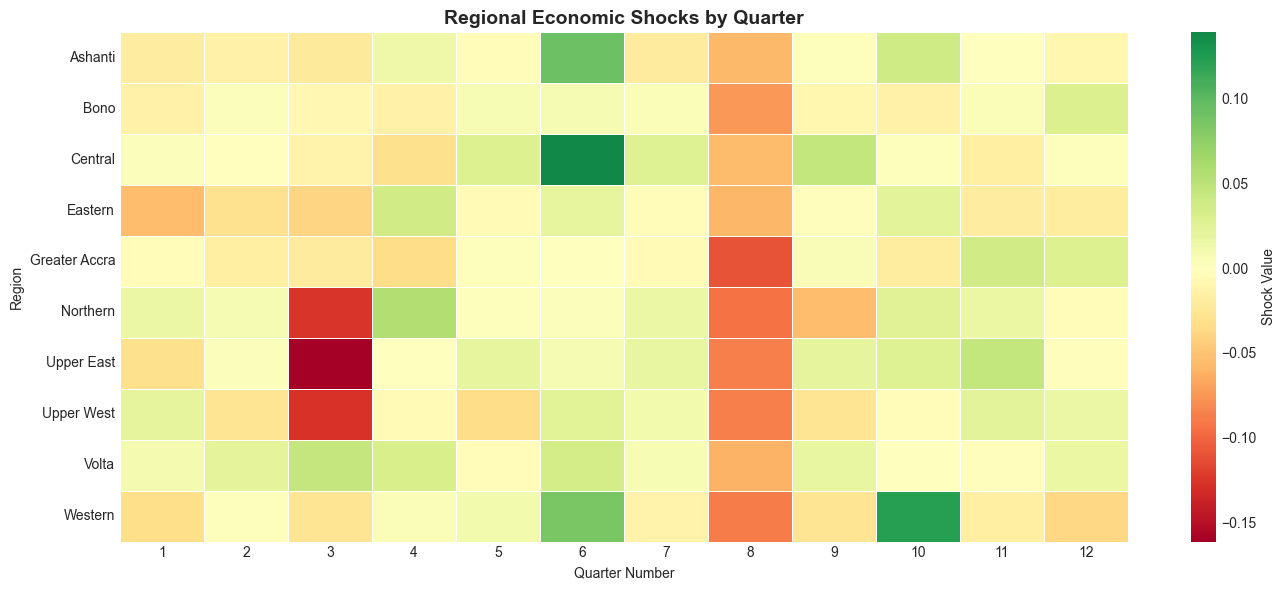

In [30]:
def generate_regional_shocks(regions, n_quarters):
    """
    Generate regional economic shocks across quarters.
    Simulates events like droughts, commodity price changes, etc.
    
    Args:
        regions: List of region names
        n_quarters: Number of quarters
    
    Returns:
        DataFrame with shock values by region and quarter
    """
    shocks = []
    
    for quarter in range(1, n_quarters + 1):
        for region in regions:
            # Base shock (small random fluctuations)
            base_shock = np.random.normal(0, 0.02)
            
            # Specific regional events
            event_shock = 0
            
            # Q3 2021: Northern regions drought
            if quarter == 3 and region in ['Northern', 'Upper East', 'Upper West']:
                event_shock = -0.15
            
            # Q2 2022: Cocoa price boom (Western, Ashanti regions)
            if quarter == 6 and region in ['Western', 'Ashanti', 'Central']:
                event_shock = 0.12
            
            # Q4 2022: Inflation surge (affects all regions)
            if quarter == 8:
                event_shock = -0.08
            
            # Q2 2023: Mining sector growth (Western region)
            if quarter == 10 and region == 'Western':
                event_shock = 0.10
            
            total_shock = base_shock + event_shock
            
            shocks.append({
                'quarter_num': quarter,
                'region': region,
                'shock_value': round(total_shock, 4),
                'shock_description': 'Economic event' if abs(event_shock) > 0.05 else 'Normal'
            })
    
    return pd.DataFrame(shocks)

# Generate regional shocks
regional_shocks_df = generate_regional_shocks(CONFIG['regions'], CONFIG['n_quarters'])

print("Regional economic shocks generated")
print(f"\nMajor shock events:")
major_shocks = regional_shocks_df[abs(regional_shocks_df['shock_value']) > 0.05]
print(major_shocks[['quarter_num', 'region', 'shock_value', 'shock_description']])

# Visualize shocks
plt.figure(figsize=(14, 6))
pivot_shocks = regional_shocks_df.pivot(index='quarter_num', columns='region', values='shock_value')
sns.heatmap(pivot_shocks.T, cmap='RdYlGn', center=0, annot=False, 
            cbar_kws={'label': 'Shock Value'}, linewidths=0.5)
plt.title('Regional Economic Shocks by Quarter', fontsize=14, fontweight='bold')
plt.xlabel('Quarter Number')
plt.ylabel('Region')
plt.tight_layout()
plt.show()

# Generate Complete Dataset 

In [31]:
def generate_complete_dataset(bank_profiles, regional_shocks, n_quarters):
    """
    Generate complete quarterly dataset for all banks.
    
    Args:
        bank_profiles: DataFrame with bank profile information
        regional_shocks: DataFrame with regional shock values
        n_quarters: Number of quarters to generate
    
    Returns:
        DataFrame with complete quarterly data
    """
    all_data = []
    
    print("Generating quarterly data for all banks...")
    
    for idx, bank in bank_profiles.iterrows():
        if (idx + 1) % 50 == 0:
            print(f"  Processing bank {idx + 1}/{len(bank_profiles)}...")
        
        previous_quarter_data = None
        
        for quarter in range(1, n_quarters + 1):
            # Get regional shock for this bank's region and quarter
            shock_mask = (regional_shocks['quarter_num'] == quarter) & \
                        (regional_shocks['region'] == bank['region'])
            regional_shock = regional_shocks[shock_mask]['shock_value'].values[0]
            
            # Generate quarterly data
            quarterly_data = generate_quarterly_data(
                bank.to_dict(),
                quarter,
                previous_quarter_data,
                regional_shock
            )
            
            # Combine bank profile with quarterly data
            record = {
                'bank_id': bank['bank_id'],
                'bank_name': bank['bank_name'],
                'region': bank['region'],
                'bank_size': bank['bank_size'],
                'lending_style': bank['lending_style'],
                **quarterly_data
            }
            
            all_data.append(record)
            previous_quarter_data = quarterly_data
    
    print(f"\nGeneration complete! Total records: {len(all_data):,}")
    return pd.DataFrame(all_data)

# Generate complete dataset
banking_data = generate_complete_dataset(
    bank_profiles_df,
    regional_shocks_df,
    CONFIG['n_quarters']
)

print(f"\nDataset shape: {banking_data.shape}")
print(f"Features: {banking_data.shape[1]}")
print(f"\nFirst few records:")
banking_data.head()

Generating quarterly data for all banks...
  Processing bank 50/224...
  Processing bank 100/224...
  Processing bank 150/224...
  Processing bank 200/224...

Generation complete! Total records: 2,688

Dataset shape: (2688, 32)
Features: 32

First few records:


,bank_id,bank_name,region,bank_size,lending_style,quarter_num,year,quarter,date,total_assets,...,net_income,return_on_assets,return_on_equity,net_interest_margin,operating_expenses,cost_to_income_ratio,staff_count,branches,concentration_risk,deposit_volatility
0,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,1,2021,Q1,2021-Q1,47.72,...,2.46,5.16,30.85,11.55,1.80,70.52,57,6,30.82,17.38
1,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,2,2021,Q2,2021-Q2,49.23,...,2.20,4.47,26.32,7.21,1.69,92.28,80,10,49.16,26.72
2,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,3,2021,Q3,2021-Q3,44.00,...,2.74,6.22,36.58,7.56,2.36,50.34,29,11,23.67,8.46
3,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,4,2021,Q4,2021-Q4,47.60,...,1.80,3.78,22.31,6.81,3.53,64.47,55,7,40.76,29.12
4,BANK_001,"Rodriguez, Figueroa and Sanchez Rural Bank",Upper West,Small,Moderate,5,2022,Q1,2022-Q1,51.87,...,0.53,1.03,6.05,3.85,2.55,90.62,25,2,17.37,7.66


# Target Variable: Financial Health Status 

Target Variable Created: financial_health_status

Class Distribution:
  HEALTHY (0): 1,767 (65.7%)
  HIGH_RISK (1): 921 (34.3%)

Risk Reason Breakdown (HIGH_RISK cases):
  Low Liquidity: 297 (32.2%)
  Low Capital: 465 (50.5%)
  High NPL: 486 (52.8%)
  Low ROE: 0 (0.0%)
  Persistent Losses: 0 (0.0%)


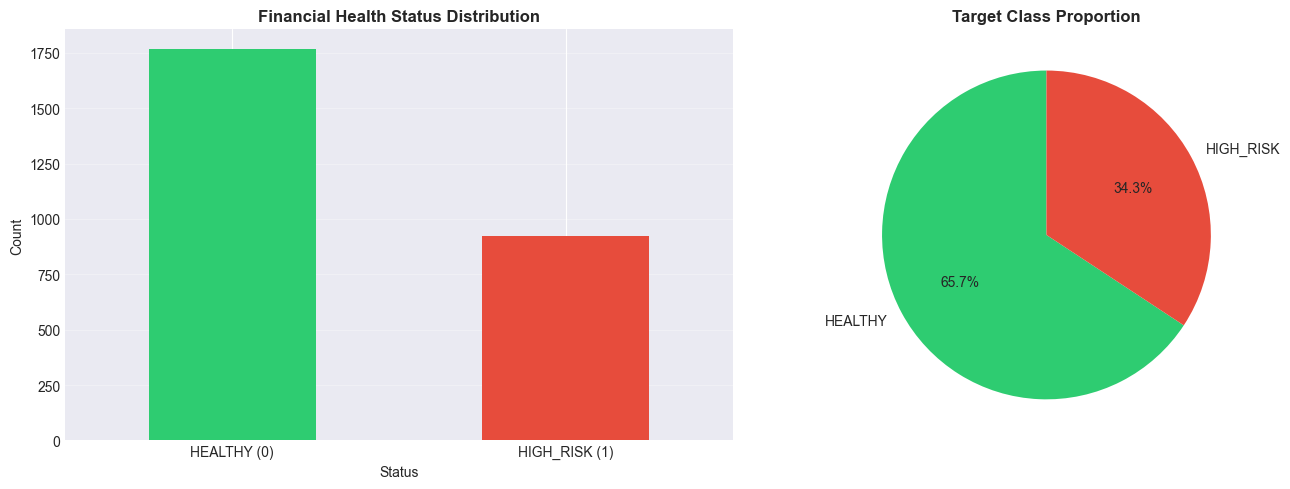

In [32]:
def create_target_variable(df):
    """
    Create binary target variable based on regulatory risk criteria.
    
    HIGH_RISK (1) if ANY of the following:
    - Liquidity ratio < 15%
    - Capital adequacy ratio < 12%
    - NPL ratio > 15%
    - Negative income for 2+ consecutive quarters
    - ROE < -5%
    
    Args:
        df: DataFrame with banking data
    
    Returns:
        DataFrame with target variable added
    """
    df = df.copy()
    
    # Initialize target as 0 (HEALTHY)
    df['financial_health_status'] = 0
    
    # Criterion 1: Low liquidity
    low_liquidity = df['liquidity_ratio'] < 15
    
    # Criterion 2: Low capital adequacy
    low_capital = df['capital_adequacy_ratio'] < 12
    
    # Criterion 3: High NPL
    high_npl = df['npl_ratio'] > 15
    
    # Criterion 4: Very low ROE
    low_roe = df['return_on_equity'] < -5
    
    # Criterion 5: Negative income for 2+ consecutive quarters
    df['consecutive_losses'] = 0
    for bank_id in df['bank_id'].unique():
        bank_mask = df['bank_id'] == bank_id
        bank_data = df[bank_mask].sort_values('quarter_num')
        
        consecutive_count = 0
        max_consecutive = 0
        
        for idx, row in bank_data.iterrows():
            if row['net_income'] < 0:
                consecutive_count += 1
                max_consecutive = max(max_consecutive, consecutive_count)
            else:
                consecutive_count = 0
            
            df.loc[idx, 'consecutive_losses'] = max_consecutive
    
    persistent_losses = df['consecutive_losses'] >= 2
    
    # Mark as HIGH_RISK if any criterion is met
    high_risk_mask = low_liquidity | low_capital | high_npl | low_roe | persistent_losses
    df.loc[high_risk_mask, 'financial_health_status'] = 1
    
    # Create risk reason for analysis
    df['risk_reasons'] = ''
    df.loc[low_liquidity, 'risk_reasons'] += 'Low Liquidity; '
    df.loc[low_capital, 'risk_reasons'] += 'Low Capital; '
    df.loc[high_npl, 'risk_reasons'] += 'High NPL; '
    df.loc[low_roe, 'risk_reasons'] += 'Low ROE; '
    df.loc[persistent_losses, 'risk_reasons'] += 'Persistent Losses; '
    
    return df

# Create target variable
banking_data = create_target_variable(banking_data)

# Analyze target distribution
print("Target Variable Created: financial_health_status")
print("\nClass Distribution:")
target_counts = banking_data['financial_health_status'].value_counts()
target_pct = banking_data['financial_health_status'].value_counts(normalize=True) * 100

print(f"  HEALTHY (0): {target_counts[0]:,} ({target_pct[0]:.1f}%)")
print(f"  HIGH_RISK (1): {target_counts[1]:,} ({target_pct[1]:.1f}%)")

print("\nRisk Reason Breakdown (HIGH_RISK cases):")
high_risk_data = banking_data[banking_data['financial_health_status'] == 1]
for reason in ['Low Liquidity', 'Low Capital', 'High NPL', 'Low ROE', 'Persistent Losses']:
    count = high_risk_data['risk_reasons'].str.contains(reason).sum()
    pct = (count / len(high_risk_data)) * 100
    print(f"  {reason}: {count:,} ({pct:.1f}%)")

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
target_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Financial Health Status Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['HEALTHY (0)', 'HIGH_RISK (1)'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# Pie chart
axes[1].pie(target_counts, labels=['HEALTHY', 'HIGH_RISK'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Target Class Proportion', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Adding missing values 


In [33]:
def introduce_missing_values(df, missing_rate=0.05, columns_to_affect=None):
    """
    Introduce realistic missing values in operational metrics.
    
    Args:
        df: DataFrame
        missing_rate: Proportion of values to make missing
        columns_to_affect: List of column names to introduce missingness
    
    Returns:
        DataFrame with missing values
    """
    df = df.copy()
    
    if columns_to_affect is None:
        # Primarily affect operational metrics
        columns_to_affect = [
            'staff_count',
            'branches',
            'operating_expenses',
            'cost_to_income_ratio',
            'concentration_risk',
            'deposit_volatility'
        ]
    
    for col in columns_to_affect:
        if col in df.columns:
            # Randomly select indices to make missing
            n_missing = int(len(df) * missing_rate)
            missing_indices = np.random.choice(df.index, size=n_missing, replace=False)
            df.loc[missing_indices, col] = np.nan
    
    return df

# Introduce missing values
banking_data = introduce_missing_values(banking_data, CONFIG['missing_rate'])

# Analyze missing values
print("Missing Values Introduced")
print("\nMissing Value Summary:")
missing_summary = banking_data.isnull().sum()
missing_summary = missing_summary[missing_summary > 0].sort_values(ascending=False)

if len(missing_summary) > 0:
    for col, count in missing_summary.items():
        pct = (count / len(banking_data)) * 100
        print(f"  {col}: {count} ({pct:.2f}%)")
else:
    print("  No missing values")

print(f"\nTotal missing values: {banking_data.isnull().sum().sum()}")
print(f"Percentage of data missing: {(banking_data.isnull().sum().sum() / banking_data.size) * 100:.2f}%")

Missing Values Introduced

Missing Value Summary:
  operating_expenses: 134 (4.99%)
  cost_to_income_ratio: 134 (4.99%)
  staff_count: 134 (4.99%)
  branches: 134 (4.99%)
  concentration_risk: 134 (4.99%)
  deposit_volatility: 134 (4.99%)

Total missing values: 804
Percentage of data missing: 0.85%


# Data Validation and Quality Checks 

In [34]:
def validate_dataset(df):
    """
    Perform comprehensive data validation checks.
    
    Args:
        df: DataFrame to validate
    
    Returns:
        Dictionary with validation results
    """
    validation_results = {}
    
    # 1. Check record count
    expected_records = CONFIG['n_banks'] * CONFIG['n_quarters']
    validation_results['record_count'] = {
        'expected': expected_records,
        'actual': len(df),
        'passed': len(df) == expected_records
    }
    
    # 2. Check unique banks
    validation_results['unique_banks'] = {
        'expected': CONFIG['n_banks'],
        'actual': df['bank_id'].nunique(),
        'passed': df['bank_id'].nunique() == CONFIG['n_banks']
    }
    
    # 3. Check quarters per bank
    quarters_per_bank = df.groupby('bank_id').size()
    validation_results['quarters_per_bank'] = {
        'expected': CONFIG['n_quarters'],
        'min': quarters_per_bank.min(),
        'max': quarters_per_bank.max(),
        'passed': (quarters_per_bank == CONFIG['n_quarters']).all()
    }
    
    # 4. Check target distribution
    high_risk_pct = (df['financial_health_status'] == 1).mean() * 100
    validation_results['target_distribution'] = {
        'high_risk_percentage': high_risk_pct,
        'expected_range': '30-35%',
        'passed': 25 <= high_risk_pct <= 40  # Allow some flexibility
    }
    
    # 5. Check logical constraints
    constraints_passed = True
    constraint_checks = []
    
    # Loans should not exceed deposits * 0.95
    check1 = (df['total_loans'] <= df['current_deposits'] * 0.95).all()
    constraint_checks.append(('Loans <= Deposits * 0.95', check1))
    
    # NPL should not exceed total loans
    check2 = (df['non_performing_loans'] <= df['total_loans']).all()
    constraint_checks.append(('NPL <= Total Loans', check2))
    
    # Equity should be positive for healthy banks
    check3 = (df['total_equity'] > 0).all()
    constraint_checks.append(('Equity > 0', check3))
    
    # Liquid assets should not exceed total assets
    check4 = (df['liquid_assets'] <= df['total_assets']).all()
    constraint_checks.append(('Liquid Assets <= Total Assets', check4))
    
    validation_results['logical_constraints'] = {
        'checks': constraint_checks,
        'passed': all([c[1] for c in constraint_checks])
    }
    
    # 6. Check for extreme outliers
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    outlier_summary = []
    
    for col in numeric_cols:
        if col not in ['quarter_num', 'year', 'consecutive_losses', 'financial_health_status']:
            Q1 = df[col].quantile(0.01)
            Q3 = df[col].quantile(0.99)
            outliers = ((df[col] < Q1) | (df[col] > Q3)).sum()
            outlier_pct = (outliers / len(df)) * 100
            outlier_summary.append((col, outliers, outlier_pct))
    
    validation_results['outliers'] = outlier_summary
    
    return validation_results

# Run validation
validation_results = validate_dataset(banking_data)

print("=" * 60)
print("DATA VALIDATION REPORT")
print("=" * 60)

# Record count
rc = validation_results['record_count']
status = "✓ PASS" if rc['passed'] else "✗ FAIL"
print(f"\n1. Record Count: {status}")
print(f"   Expected: {rc['expected']:,} | Actual: {rc['actual']:,}")

# Unique banks
ub = validation_results['unique_banks']
status = "✓ PASS" if ub['passed'] else "✗ FAIL"
print(f"\n2. Unique Banks: {status}")
print(f"   Expected: {ub['expected']} | Actual: {ub['actual']}")

# Quarters per bank
qpb = validation_results['quarters_per_bank']
status = "✓ PASS" if qpb['passed'] else "✗ FAIL"
print(f"\n3. Quarters per Bank: {status}")
print(f"   Expected: {qpb['expected']} | Min: {qpb['min']} | Max: {qpb['max']}")

# Target distribution
td = validation_results['target_distribution']
status = "✓ PASS" if td['passed'] else "✗ FAIL"
print(f"\n4. Target Distribution: {status}")
print(f"   High-Risk %: {td['high_risk_percentage']:.1f}% | Expected: {td['expected_range']}")

# Logical constraints
lc = validation_results['logical_constraints']
status = "✓ PASS" if lc['passed'] else "✗ FAIL"
print(f"\n5. Logical Constraints: {status}")
for check_name, check_passed in lc['checks']:
    check_status = "✓" if check_passed else "✗"
    print(f"   {check_status} {check_name}")

# Outliers summary
print(f"\n6. Outlier Detection (1st-99th percentile):")
outlier_data = validation_results['outliers']
outlier_df = pd.DataFrame(outlier_data, columns=['Feature', 'Count', 'Percentage'])
outlier_df = outlier_df[outlier_df['Percentage'] > 5].sort_values('Percentage', ascending=False)
if len(outlier_df) > 0:
    print(outlier_df.head(10).to_string(index=False))
else:
    print("   No significant outliers detected (>5%)")

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

DATA VALIDATION REPORT

1. Record Count: ✓ PASS
   Expected: 2,688 | Actual: 2,688

2. Unique Banks: ✓ PASS
   Expected: 224 | Actual: 224

3. Quarters per Bank: ✓ PASS
   Expected: 12 | Min: 12 | Max: 12

4. Target Distribution: ✓ PASS
   High-Risk %: 34.3% | Expected: 30-35%

5. Logical Constraints: ✓ PASS
   ✓ Loans <= Deposits * 0.95
   ✓ NPL <= Total Loans
   ✓ Equity > 0
   ✓ Liquid Assets <= Total Assets

6. Outlier Detection (1st-99th percentile):
   No significant outliers detected (>5%)

VALIDATION COMPLETE


In [35]:
# Display comprehensive summary statistics
print("DATASET SUMMARY STATISTICS")
print("=" * 80)

print(f"\nDataset Shape: {banking_data.shape}")
print(f"Number of Banks: {banking_data['bank_id'].nunique()}")
print(f"Number of Quarters: {banking_data['quarter_num'].nunique()}")
print(f"Total Records: {len(banking_data):,}")

print("\n" + "-" * 80)
print("FEATURE SUMMARY")
print("-" * 80)

# Numeric columns summary
numeric_cols = banking_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['quarter_num', 'year', 'consecutive_losses']]

summary_stats = banking_data[numeric_cols].describe().T
summary_stats['missing'] = banking_data[numeric_cols].isnull().sum()
summary_stats['missing_pct'] = (summary_stats['missing'] / len(banking_data)) * 100

print("\nKey Financial Metrics:")
key_metrics = ['liquidity_ratio', 'capital_adequacy_ratio', 'npl_ratio', 
               'return_on_assets', 'return_on_equity', 'loan_to_deposit_ratio']
print(summary_stats.loc[key_metrics, ['mean', 'std', 'min', 'max', 'missing_pct']].round(2))

print("\n" + "-" * 80)
print("CATEGORICAL FEATURES")
print("-" * 80)

print("\nBank Size Distribution:")
print(banking_data['bank_size'].value_counts())

print("\nRegional Distribution:")
print(banking_data['region'].value_counts())

print("\nLending Style Distribution:")
print(banking_data['lending_style'].value_counts())

print("\n" + "=" * 80)

DATASET SUMMARY STATISTICS

Dataset Shape: (2688, 35)
Number of Banks: 224
Number of Quarters: 12
Total Records: 2,688

--------------------------------------------------------------------------------
FEATURE SUMMARY
--------------------------------------------------------------------------------

Key Financial Metrics:
                         mean    std    min    max  missing_pct
liquidity_ratio         25.65   8.91   4.29  48.96          0.0
capital_adequacy_ratio  18.77   6.39   7.81  30.73          0.0
npl_ratio                9.63   6.32   0.27  29.26          0.0
return_on_assets         3.48   1.44   0.78   6.29          0.0
return_on_equity        21.22  12.67   3.40  73.48          0.0
loan_to_deposit_ratio   67.34  15.97  40.02  94.99          0.0

--------------------------------------------------------------------------------
CATEGORICAL FEATURES
--------------------------------------------------------------------------------

Bank Size Distribution:
bank_size
Small     1

## Feature Correlation Analysis

FEATURE CORRELATION WITH TARGET (financial_health_status)

Top 10 Positive Correlations (Higher value → Higher risk):
npl_ratio                0.479845
return_on_equity         0.322165
non_performing_loans     0.174009
loan_loss_provisions     0.168381
return_on_assets         0.012680
concentration_risk       0.009642
loan_to_deposit_ratio    0.001476
cost_to_income_ratio    -0.006391
net_interest_margin     -0.017957
leverage_ratio          -0.018615
Name: financial_health_status, dtype: float64

Top 10 Negative Correlations (Higher value → Lower risk):
operating_expenses       -0.045282
total_loans              -0.049646
total_assets             -0.052836
current_deposits         -0.054592
branches                 -0.066726
staff_count              -0.098432
total_equity             -0.113080
liquid_assets            -0.144346
liquidity_ratio          -0.367956
capital_adequacy_ratio   -0.383559
Name: financial_health_status, dtype: float64


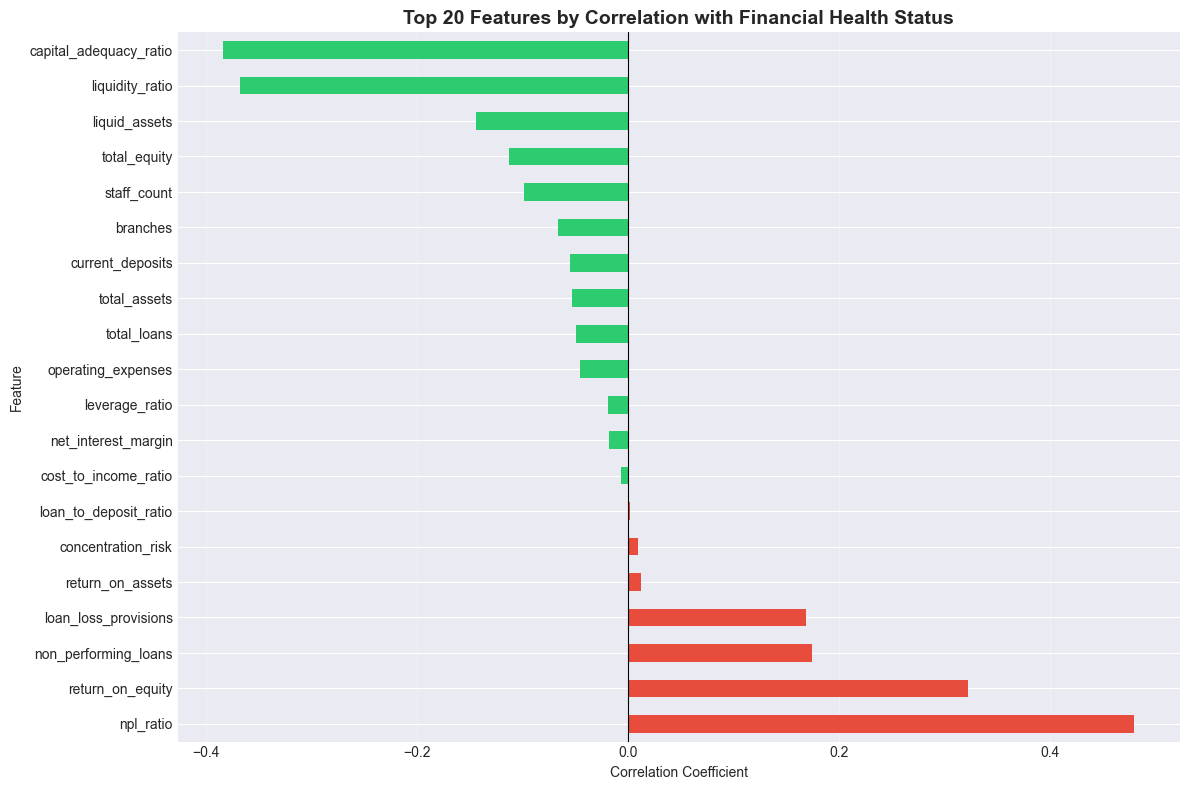

In [23]:
# Calculate correlation with target variable
numeric_features = banking_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f not in ['quarter_num', 'year', 'consecutive_losses', 'financial_health_status']]

correlations_with_target = banking_data[numeric_features + ['financial_health_status']].corr()['financial_health_status'].sort_values(ascending=False)
correlations_with_target = correlations_with_target[correlations_with_target.index != 'financial_health_status']

print("FEATURE CORRELATION WITH TARGET (financial_health_status)")
print("=" * 60)
print("\nTop 10 Positive Correlations (Higher value → Higher risk):")
print(correlations_with_target.head(10))
print("\nTop 10 Negative Correlations (Higher value → Lower risk):")
print(correlations_with_target.tail(10))

# Visualize top correlations
fig, ax = plt.subplots(figsize=(12, 8))
top_features = pd.concat([correlations_with_target.head(10), correlations_with_target.tail(10)])
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in top_features.values]

top_features.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Top 20 Features by Correlation with Financial Health Status', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Feature')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [39]:
# Create data directories
os.makedirs('data/raw', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)

# Save raw dataset
raw_file_path = 'data/raw/banking_data_raw.csv'
banking_data.to_csv(raw_file_path, index=False)
print(f"Raw dataset saved to: {raw_file_path}")
print(f"File size: {os.path.getsize(raw_file_path) / 1024:.2f} KB")

# Save bank profiles
profiles_file_path = 'data/raw/bank_profiles.csv'
bank_profiles_df.to_csv(profiles_file_path, index=False)
print(f"\nBank profiles saved to: {profiles_file_path}")

# Save regional shocks
shocks_file_path = 'data/raw/regional_shocks.csv'
regional_shocks_df.to_csv(shocks_file_path, index=False)
print(f"Regional shocks saved to: {shocks_file_path}")

print("DATA GENERATION COMPLETE")
print(f"\nTotal banks: {banking_data['bank_id'].nunique()}")
print(f"Total quarters: {banking_data['quarter_num'].nunique()}")
print(f"Total records: {len(banking_data):,}")
print(f"Features: {banking_data.shape[1]}")
print(f"\nTarget Distribution:")
print(f"  HEALTHY (0): {(banking_data['financial_health_status']==0).sum():,} ({(banking_data['financial_health_status']==0).mean()*100:.1f}%)")
print(f"  HIGH_RISK (1): {(banking_data['financial_health_status']==1).sum():,} ({(banking_data['financial_health_status']==1).mean()*100:.1f}%)")

Raw dataset saved to: data/raw/banking_data_raw.csv
File size: 581.14 KB

Bank profiles saved to: data/raw/bank_profiles.csv
Regional shocks saved to: data/raw/regional_shocks.csv
DATA GENERATION COMPLETE

Total banks: 224
Total quarters: 12
Total records: 2,688
Features: 35

Target Distribution:
  HEALTHY (0): 1,767 (65.7%)
  HIGH_RISK (1): 921 (34.3%)


In [38]:
# Create comprehensive data dictionary
data_dictionary = {
    'Feature': [],
    'Type': [],
    'Description': [],
    'Range/Values': []
}

feature_descriptions = [
    ('bank_id', 'Identifier', 'Unique bank identifier', 'BANK_001 to BANK_224'),
    ('bank_name', 'Text', 'Bank name', 'Generated names'),
    ('region', 'Categorical', 'Geographic region', '10 regions in Ghana'),
    ('bank_size', 'Categorical', 'Bank size category', 'Small, Medium, Large'),
    ('lending_style', 'Categorical', 'Risk appetite in lending', 'Conservative, Moderate, Aggressive'),
    ('quarter_num', 'Numeric', 'Quarter number in sequence', '1-12'),
    ('year', 'Numeric', 'Calendar year', '2021-2023'),
    ('quarter', 'Text', 'Quarter label', 'Q1-Q4'),
    ('date', 'Text', 'Period identifier', 'YYYY-QN format'),
    ('total_assets', 'Numeric', 'Total assets (millions)', 'Varies by bank size'),
    ('total_equity', 'Numeric', 'Total equity capital (millions)', 'Positive values'),
    ('liquid_assets', 'Numeric', 'Liquid assets (millions)', '< Total assets'),
    ('total_loans', 'Numeric', 'Total loan portfolio (millions)', '< Deposits * 0.95'),
    ('non_performing_loans', 'Numeric', 'NPL amount (millions)', '< Total loans'),
    ('loan_loss_provisions', 'Numeric', 'Loan loss provisions (millions)', '~0.5-1.2x NPL'),
    ('current_deposits', 'Numeric', 'Customer deposits (millions)', '~70-85% of assets'),
    ('liquidity_ratio', 'Ratio', 'Liquid assets / Total assets (%)', '5-45%'),
    ('capital_adequacy_ratio', 'Ratio', 'Equity / Risk-weighted assets (%)', '8-30%'),
    ('cash_reserve_ratio', 'Ratio', 'Cash reserves / Deposits (%)', '8-25%'),
    ('leverage_ratio', 'Ratio', 'Assets / Equity', '5-20x'),
    ('loan_to_deposit_ratio', 'Ratio', 'Loans / Deposits (%)', '40-95%'),
    ('npl_ratio', 'Ratio', 'NPL / Total loans (%)', '0-25%'),
    ('net_income', 'Numeric', 'Net income (millions)', 'Can be negative'),
    ('return_on_assets', 'Ratio', 'Net income / Total assets (%)', '-5% to 8%'),
    ('return_on_equity', 'Ratio', 'Net income / Equity (%)', '-15% to 25%'),
    ('net_interest_margin', 'Ratio', 'Interest margin (%)', '2-12%'),
    ('operating_expenses', 'Numeric', 'Operating costs (millions)', '~3-8% of assets'),
    ('cost_to_income_ratio', 'Ratio', 'Operating expenses / Income (%)', '30-95%'),
    ('staff_count', 'Numeric', 'Number of employees', 'Size-dependent'),
    ('branches', 'Numeric', 'Number of branches', 'Size-dependent'),
    ('concentration_risk', 'Ratio', 'Loan concentration risk (%)', '15-60%'),
    ('deposit_volatility', 'Ratio', 'Deposit volatility measure (%)', '5-35%'),
    ('consecutive_losses', 'Numeric', 'Max consecutive loss quarters', '0-12'),
    ('financial_health_status', 'Binary', 'TARGET: Risk classification', '0=HEALTHY, 1=HIGH_RISK'),
    ('risk_reasons', 'Text', 'Risk criteria met (if HIGH_RISK)', 'Multiple reasons possible')
]

for feature, ftype, desc, range_val in feature_descriptions:
    data_dictionary['Feature'].append(feature)
    data_dictionary['Type'].append(ftype)
    data_dictionary['Description'].append(desc)
    data_dictionary['Range/Values'].append(range_val)

data_dict_df = pd.DataFrame(data_dictionary)

# Save data dictionary
dict_file_path = 'data/DATA_DICTIONARY.csv'
data_dict_df.to_csv(dict_file_path, index=False)
print(f"Data dictionary saved to: {dict_file_path}")

print("\nData Dictionary:")
print(data_dict_df.to_string(index=False))

Data dictionary saved to: data/DATA_DICTIONARY.csv

Data Dictionary:
                Feature        Type                       Description                       Range/Values
                bank_id  Identifier            Unique bank identifier               BANK_001 to BANK_224
              bank_name        Text                         Bank name                    Generated names
                 region Categorical                 Geographic region                10 regions in Ghana
              bank_size Categorical                Bank size category               Small, Medium, Large
          lending_style Categorical          Risk appetite in lending Conservative, Moderate, Aggressive
            quarter_num     Numeric        Quarter number in sequence                               1-12
                   year     Numeric                     Calendar year                          2021-2023
                quarter        Text                     Quarter label                      